In [ ]:
%cd /kaggle/working
!cp -r /kaggle/input/datasets/REPLACEYOURPATH /kaggle/working/
%cd /kaggle/working/gnn-model
%pip install torch_geometric -q

/kaggle/working
/kaggle/working/gnn-model
Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torch_geometric.data import Data

from utils.data_processing import *
from utils.architecture import GIN, Transformer
from utils.train_model import train_model
from utils.evaluate_model import *

In [ ]:
class Args:
    data_dir = "/kaggle/input/datasets/REPLACEYOURPATH"  # folder containing Hexagonal, Kagome, Demi-A, Demi-B, Demi-C
    batch_num = 32
    epoch_num = 200
    cover_interval = 20
    overlap = 0.3
    save_model_dir = "/kaggle/working/saved_model"
    model = "transformer"  # "transformer" or "gin"

args = Args()
os.makedirs(args.save_model_dir, exist_ok=True)

folder_list = ["Hexagonal", "Kagome", "Demi-A", "Demi-B", "Demi-C"]
batch_size = args.batch_num
epoch_num = args.epoch_num
learning_rate = 0.001
overlap = args.overlap

## 1. Load dataset

In [6]:
def load_inp_data(file_path, label):
    nodes, edges = [], []

    with open(file_path, "r") as file:
        lines = file.readlines()

    node_section = False
    element_section = False

    for line in lines:
        line = line.strip()

        if "*Node" in line:
            node_section = True
            element_section = False
            continue

        if "*Element" in line:
            node_section = False
            element_section = True
            continue

        if "*Nset" in line or "*Elset" in line:
            node_section = False
            element_section = False
            continue

        if node_section:
            parts = line.split(",")
            if len(parts) >= 3:
                try:
                    x = float(parts[1].strip())
                    y = float(parts[2].strip())
                    nodes.append([x, y])
                except ValueError:
                    continue

        if element_section:
            parts = line.split(",")
            if (len(parts) >= 3 and parts[0].strip().isdigit() and parts[1].strip().isdigit() and parts[2].strip().isdigit()):
                start = int(parts[1].strip()) - 1
                end = int(parts[2].strip()) - 1

                if start == end:
                    continue

                if start < len(nodes) and end < len(nodes):
                    edges.append([start, end])
                else:
                    print(f"Skipping invalid edge ({start + 1}, {end + 1}) in {file_path}")

    node_tensor = torch.tensor(nodes, dtype=torch.float)
    edge_tensor = (
        torch.tensor(edges, dtype=torch.long).t().contiguous()
        if edges
        else torch.empty((2, 0), dtype=torch.long)
    )

    return Data(x=node_tensor, edge_index=edge_tensor, E=np.float64(label * 200.00))


def load_dataset(data_dir, folder_list):
    dataset = []

    for folder in folder_list:
        results_path = os.path.join(data_dir, folder, "Results.txt")
        inp_folder = os.path.join(data_dir, folder, "inp_files")

        if not os.path.exists(results_path):
            raise FileNotFoundError(f"Missing Results.txt: {results_path}")

        if not os.path.isdir(inp_folder):
            raise FileNotFoundError(f"Missing inp_files folder: {inp_folder}")

        file_labels = {}
        with open(results_path, "r") as file:
            for line in file:
                if line.strip() == "" or "E/Es" in line:
                    continue
                try:
                    file_name, label = line.strip().split(", ")
                    filename = file_name.strip().split(".")[0]
                    file_labels[filename] = float(label)
                except ValueError:
                    print(f"[{folder}] Skipping invalid line: {line.strip()}")

        for file, label in file_labels.items():
            file_path = os.path.join(inp_folder, f"{file}.inp")
            if os.path.exists(file_path):
                dataset.append(load_inp_data(file_path, label))
            else:
                print(f"[{folder}] Missing file: {file_path}")

    if len(dataset) == 0:
        raise RuntimeError("No graph data was loaded. Check --data_dir and folder names.")

    return dataset

In [7]:
dataset = load_dataset(args.data_dir, folder_list)
check_duplicate_graphs(dataset)

Number of duplicate graphs with same coordinates, edges, and E: 0


[]

## Make graphs undirected

In [8]:
all_undirected_before = all(is_undirected(data) for data in dataset)
print(f"Graphs are undirected (before conversion): {all_undirected_before}")

dataset = [make_undirected(data) for data in dataset]

all_undirected_after = all(is_undirected(data) for data in dataset)
print(f"Graphs are undirected (after conversion): {all_undirected_after}")

Graphs are undirected (before conversion): False
Graphs are undirected (after conversion): True


## Split, normalize, build loaders

In [9]:
dataset_size = len(dataset)
train_size = int(0.80 * dataset_size)
valid_size = int(0.10 * dataset_size)
test_size = dataset_size - train_size - valid_size

train_set, valid_set, test_set = random_split(
    dataset, [train_size, valid_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# Extract lists to normalize safely using Training criteria
train_list, valid_list, test_list = list(train_set), list(valid_set), list(test_set)
train_list, valid_list, test_list = normalize_planar_info(train_list, valid_list, test_list)

train_loader = DataLoader(train_list, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_list, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_list, batch_size=batch_size, shuffle=False)

## Dataset distribution

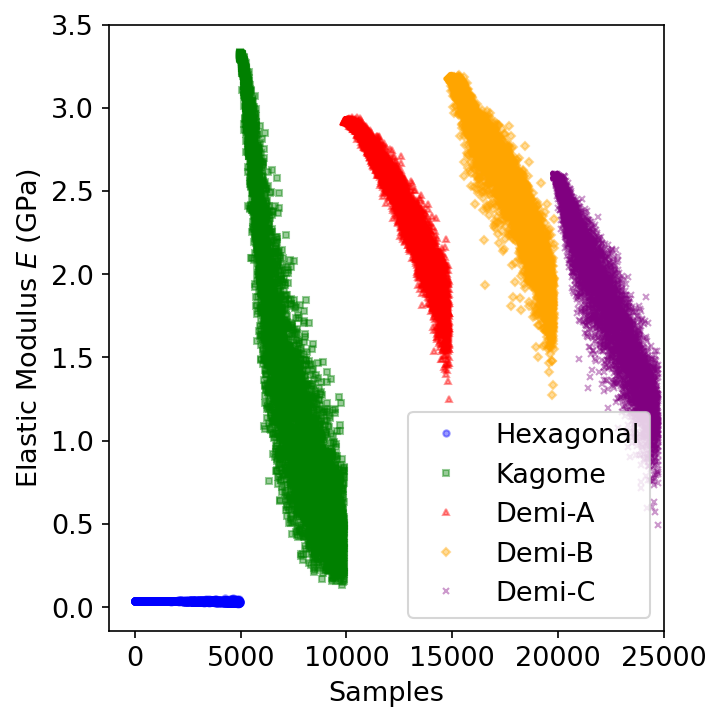

In [10]:
def plot_dataset(dataset, output_dir):
    E_vals = [data.E for data in dataset]

    plt.figure(figsize=(5, 5), dpi=150)
    plt.rcParams["font.serif"] = ["Times New Roman"]
    plt.rcParams["font.size"] = 13

    labels = ["Hexagonal", "Kagome", "Demi-A", "Demi-B", "Demi-C"]
    markers = ["o", "s", "^", "D", "x"]
    colors = ["blue", "green", "red", "orange", "purple"]

    size = 4951
    for i in range(5):
        start = i * size
        end = min((i + 1) * size, len(E_vals))
        if start >= len(E_vals):
            break
        x = range(start, end)
        y = E_vals[start:end]
        plt.plot(x, y, linestyle="none", marker=markers[i], color=colors[i], markersize=3, label=labels[i], alpha=0.4)

    plt.ylabel(r"Elastic Modulus $E$ (GPa)")
    plt.xlabel("Samples")
    plt.xlim(right=25000)
    plt.ylim(top=3.5)
    plt.legend()
    plt.tight_layout()

    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(os.path.join(output_dir, "dataset_distribution.png"))
    plt.show()


plot_dataset(dataset, args.save_model_dir)

## 2. Build model, optimizer, scheduler

In [11]:
no_node_feature = dataset[0].x.shape[1]

if args.model == "transformer":
    model = Transformer(dim_h=64, node_feature=no_node_feature)
else:
    model = GIN(dim_h=64, node_feature=no_node_feature)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
criterion = nn.MSELoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=5, factor=0.5, min_lr=1e-5)

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple GPU (MPS)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA GPU")
else:
    device = torch.device("cpu")
    print("Using CPU")

model.to(device)
print(model)
print("Device:", device)

num_params = sum(p.numel() for p in model.parameters())
print("Number of parameters:", num_params)

Using CUDA GPU
Transformer(
  (conv1): TransformerConv(2, 64, heads=4)
  (conv2): TransformerConv(256, 64, heads=4)
  (conv3): TransformerConv(256, 64, heads=4)
  (lin1): Linear(in_features=768, out_features=128, bias=True)
  (lin2): Linear(in_features=128, out_features=128, bias=True)
  (lin3): Linear(in_features=128, out_features=1, bias=True)
  (relu): ReLU()
)
Device: cuda
Number of parameters: 644481


## 3. Training

In [12]:
train_losses, valid_losses, R2_trainings, R2_valids, best_state_dict = train_model(
    model, train_loader, valid_loader, criterion,
    optimizer, scheduler, device=device, num_epochs=epoch_num,
)

Epoch [1], LR [0.001], Loss[Train: 0.477, Valid: 0.308], R2[Train: 0.564, Valid: 0.716]
Epoch [2], LR [0.001], Loss[Train: 0.329, Valid: 0.290], R2[Train: 0.699, Valid: 0.732]
Epoch [3], LR [0.001], Loss[Train: 0.324, Valid: 0.273], R2[Train: 0.703, Valid: 0.748]
Epoch [4], LR [0.001], Loss[Train: 0.311, Valid: 0.270], R2[Train: 0.715, Valid: 0.750]
Epoch [5], LR [0.001], Loss[Train: 0.302, Valid: 0.266], R2[Train: 0.724, Valid: 0.754]
Epoch [6], LR [0.001], Loss[Train: 0.300, Valid: 0.297], R2[Train: 0.725, Valid: 0.726]
Epoch [7], LR [0.001], Loss[Train: 0.290, Valid: 0.284], R2[Train: 0.735, Valid: 0.738]
Epoch [8], LR [0.001], Loss[Train: 0.299, Valid: 0.275], R2[Train: 0.726, Valid: 0.746]
Epoch [9], LR [0.001], Loss[Train: 0.291, Valid: 0.275], R2[Train: 0.734, Valid: 0.745]
Epoch [10], LR [0.001], Loss[Train: 0.285, Valid: 0.288], R2[Train: 0.740, Valid: 0.733]
Epoch [11], LR [0.0005], Loss[Train: 0.290, Valid: 0.280], R2[Train: 0.735, Valid: 0.741]
Epoch [12], LR [0.0005], Loss

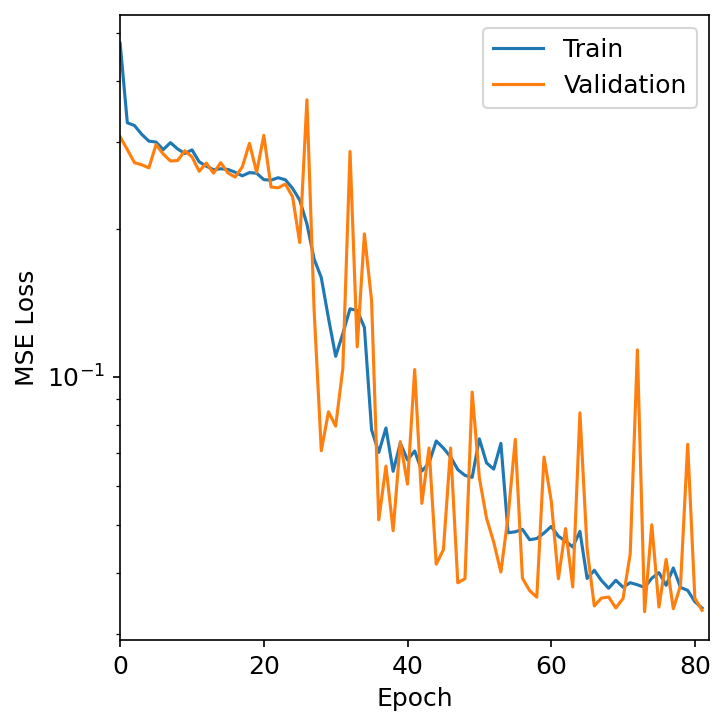

In [13]:
def plot_losses(train_losses, valid_losses, epoch_num, output_dir):
    plt.figure(figsize=(5, 5), dpi=150)
    plt.rcParams["font.serif"] = ["Times New Roman"]
    plt.rcParams["font.size"] = 12

    plt.plot(np.array(train_losses), label="Train")
    plt.plot(np.array(valid_losses), label="Validation")
    plt.legend()
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.yscale("log")
    plt.xlim(0, len(train_losses))
    plt.tight_layout()

    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(os.path.join(output_dir, "training_loss.png"))
    plt.show()


plot_losses(train_losses, valid_losses, epoch_num, args.save_model_dir)

## Save and reload best checkpoint

In [14]:
best_model_path = os.path.join(args.save_model_dir, f"epoch_{len(train_losses)}.pt")
torch.save(best_state_dict, best_model_path)
print(f"Saved best model to: {best_model_path}")

model.load_state_dict(best_state_dict)

Saved best model to: /kaggle/working/saved_model/epoch_82.pt


<All keys matched successfully>

## 4. Evaluate on train / validation / test

Train R2 for E: 0.9698999524116516
Train Bias (mean residual): 0.0124


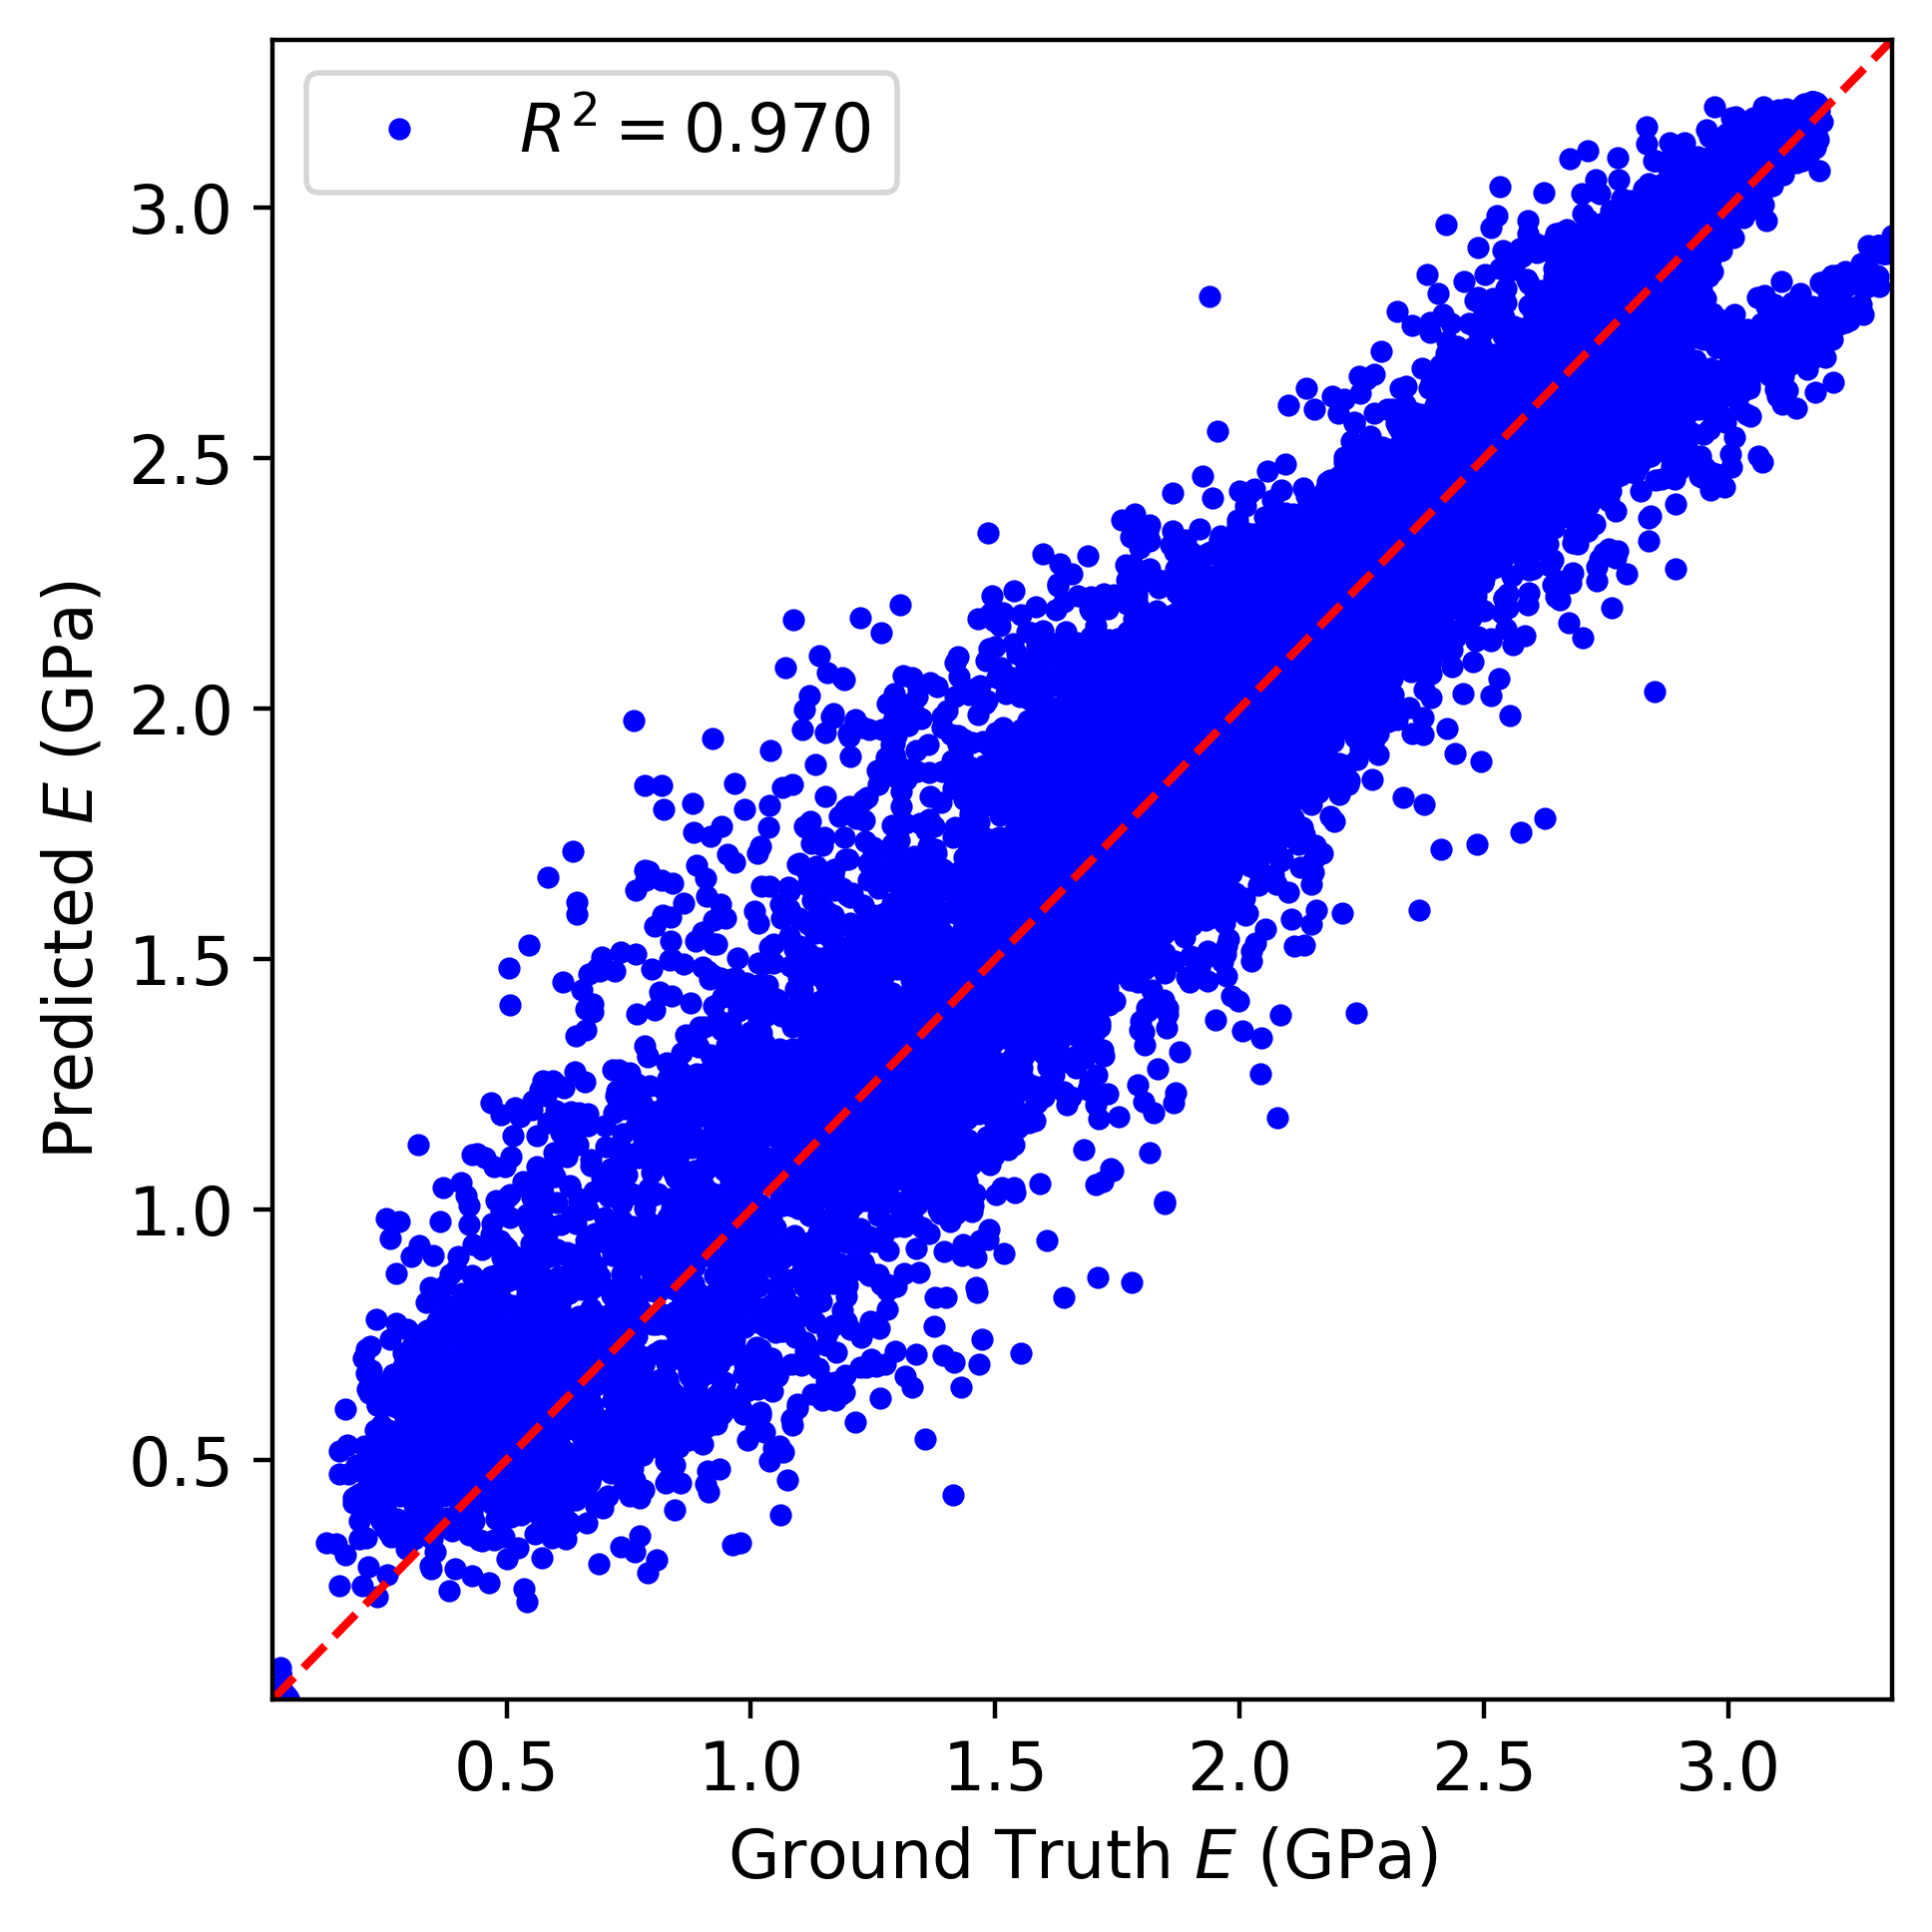

In [15]:
R2, bias = evaluate_model(model, train_loader, device, args.cover_interval, overlap, args.save_model_dir, split_name="train")

Validation R2 for E: 0.9683654308319092
Validation Bias (mean residual): 0.0145


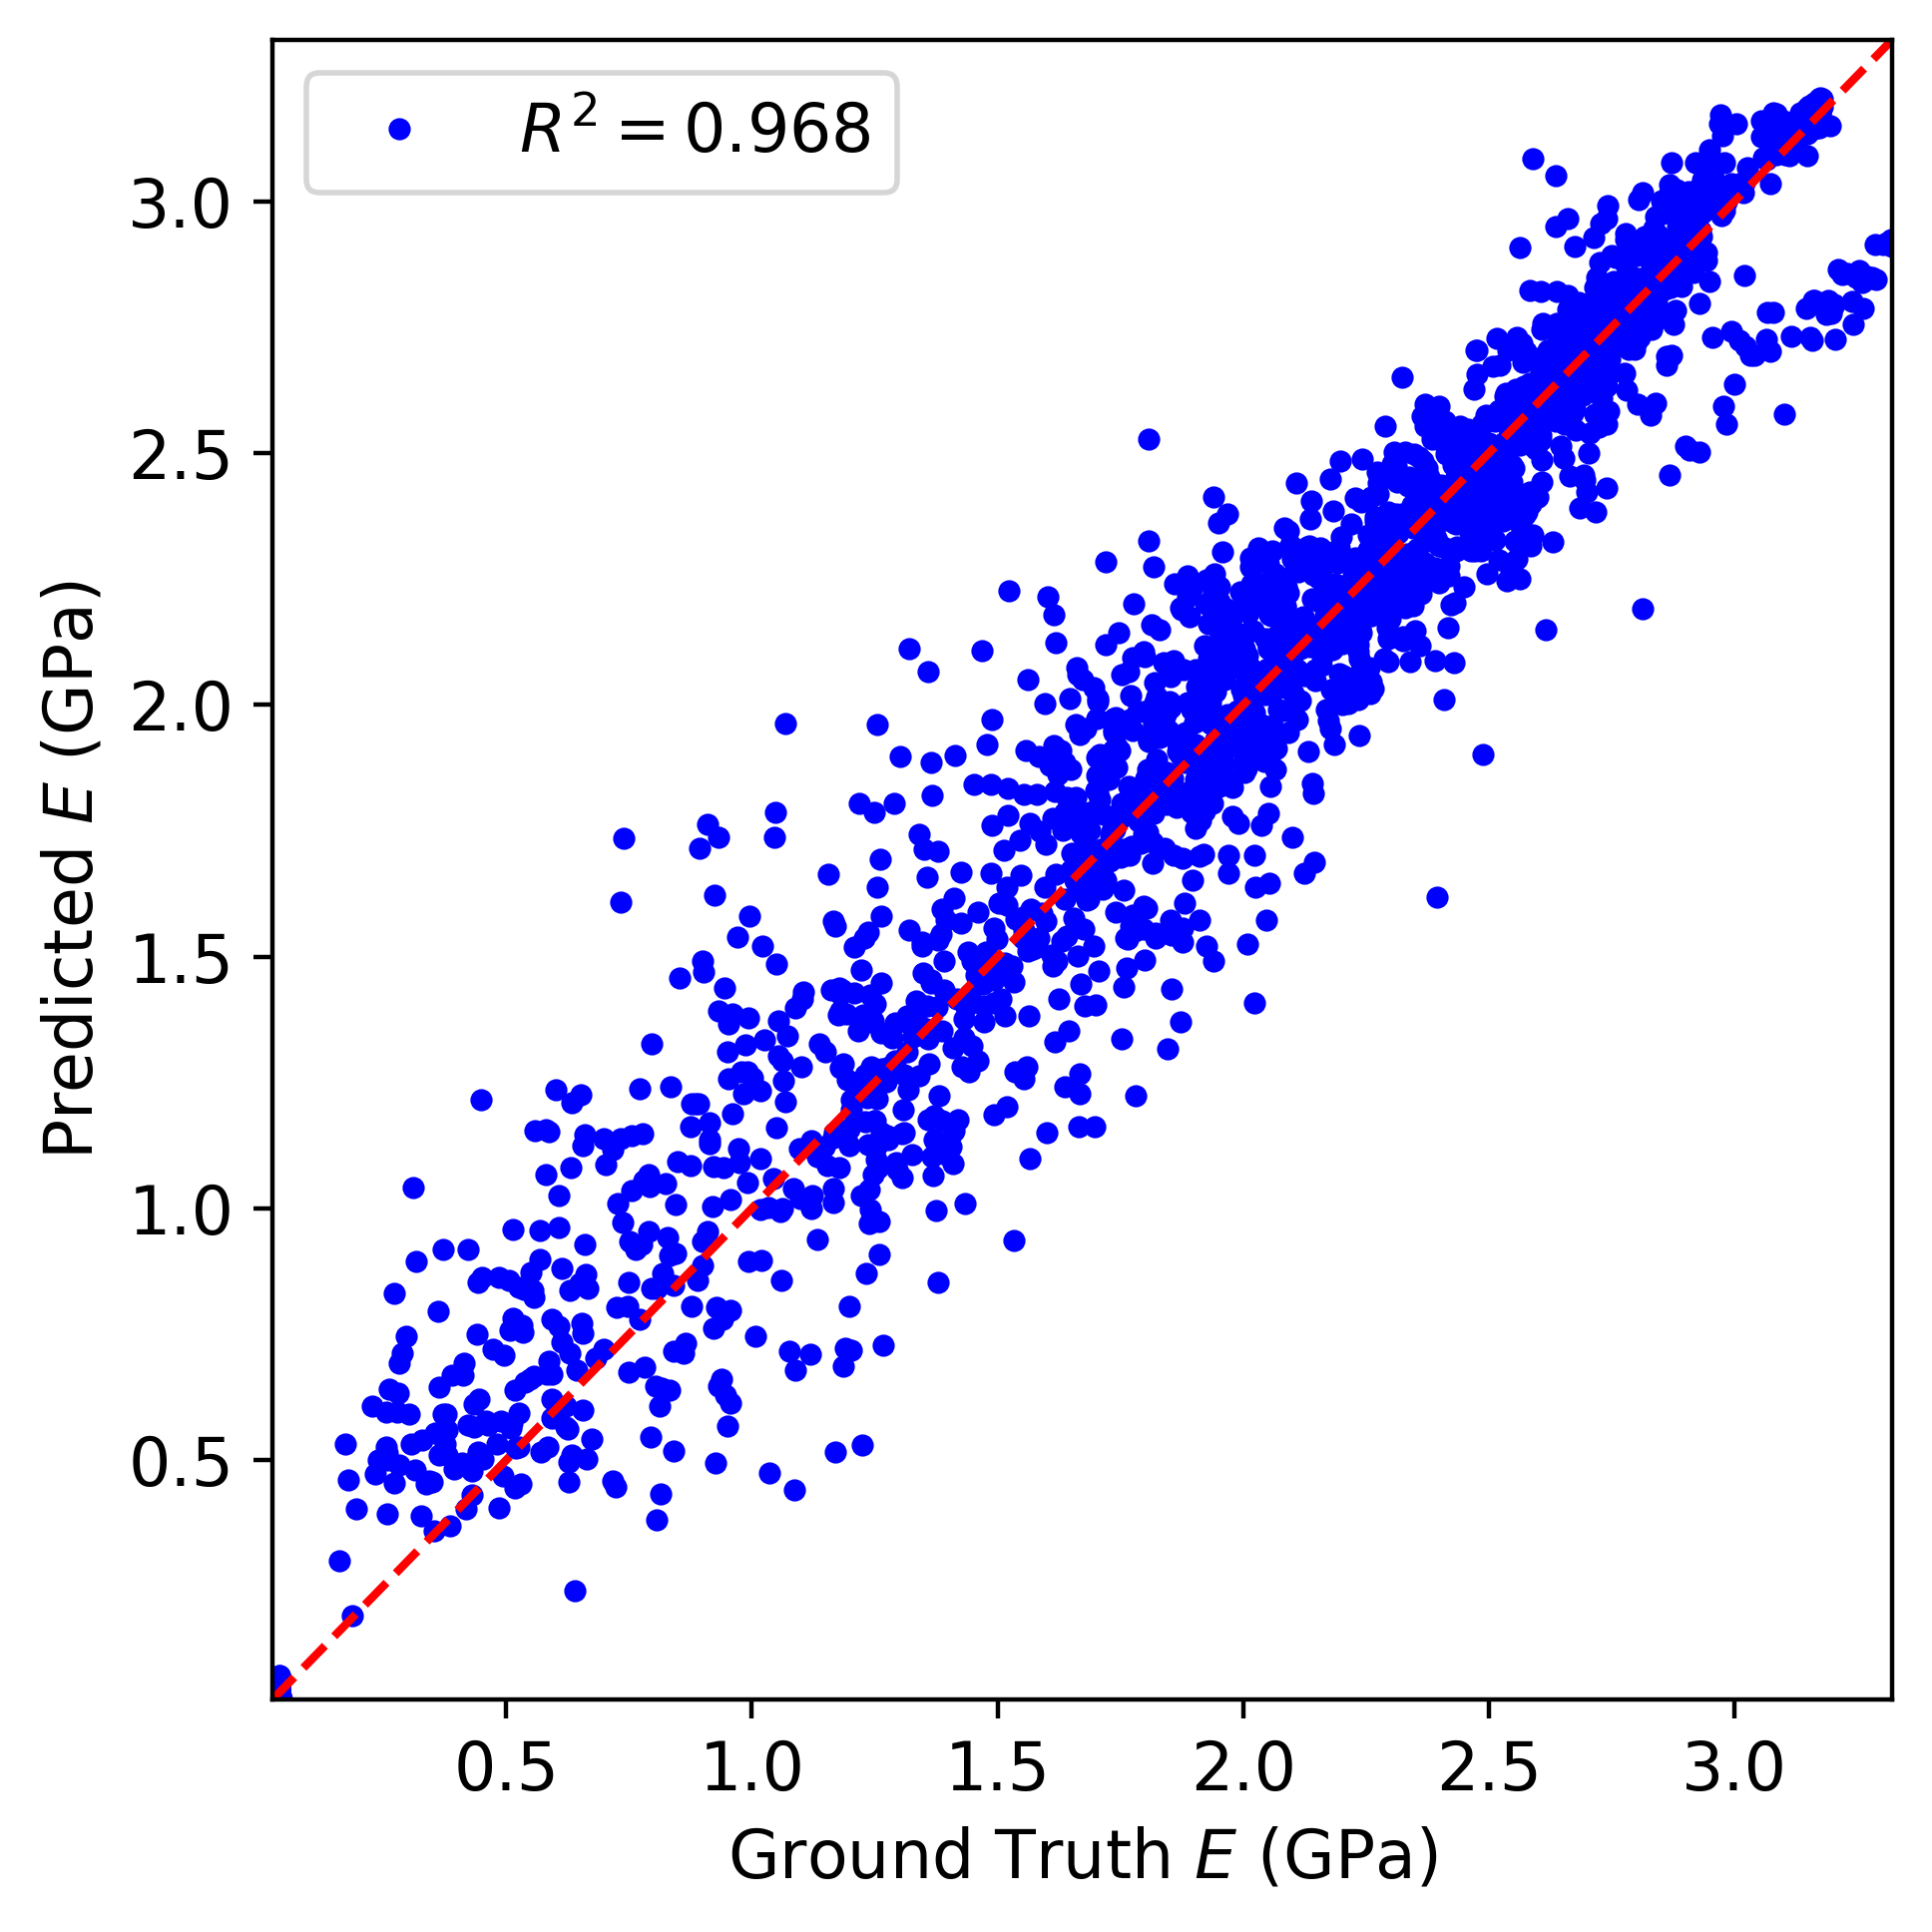

In [16]:
R2, bias = evaluate_model(model, valid_loader, device, args.cover_interval, overlap, args.save_model_dir, split_name="validation")

Test R2 for E: 0.971486508846283
Test Bias (mean residual): 0.0131


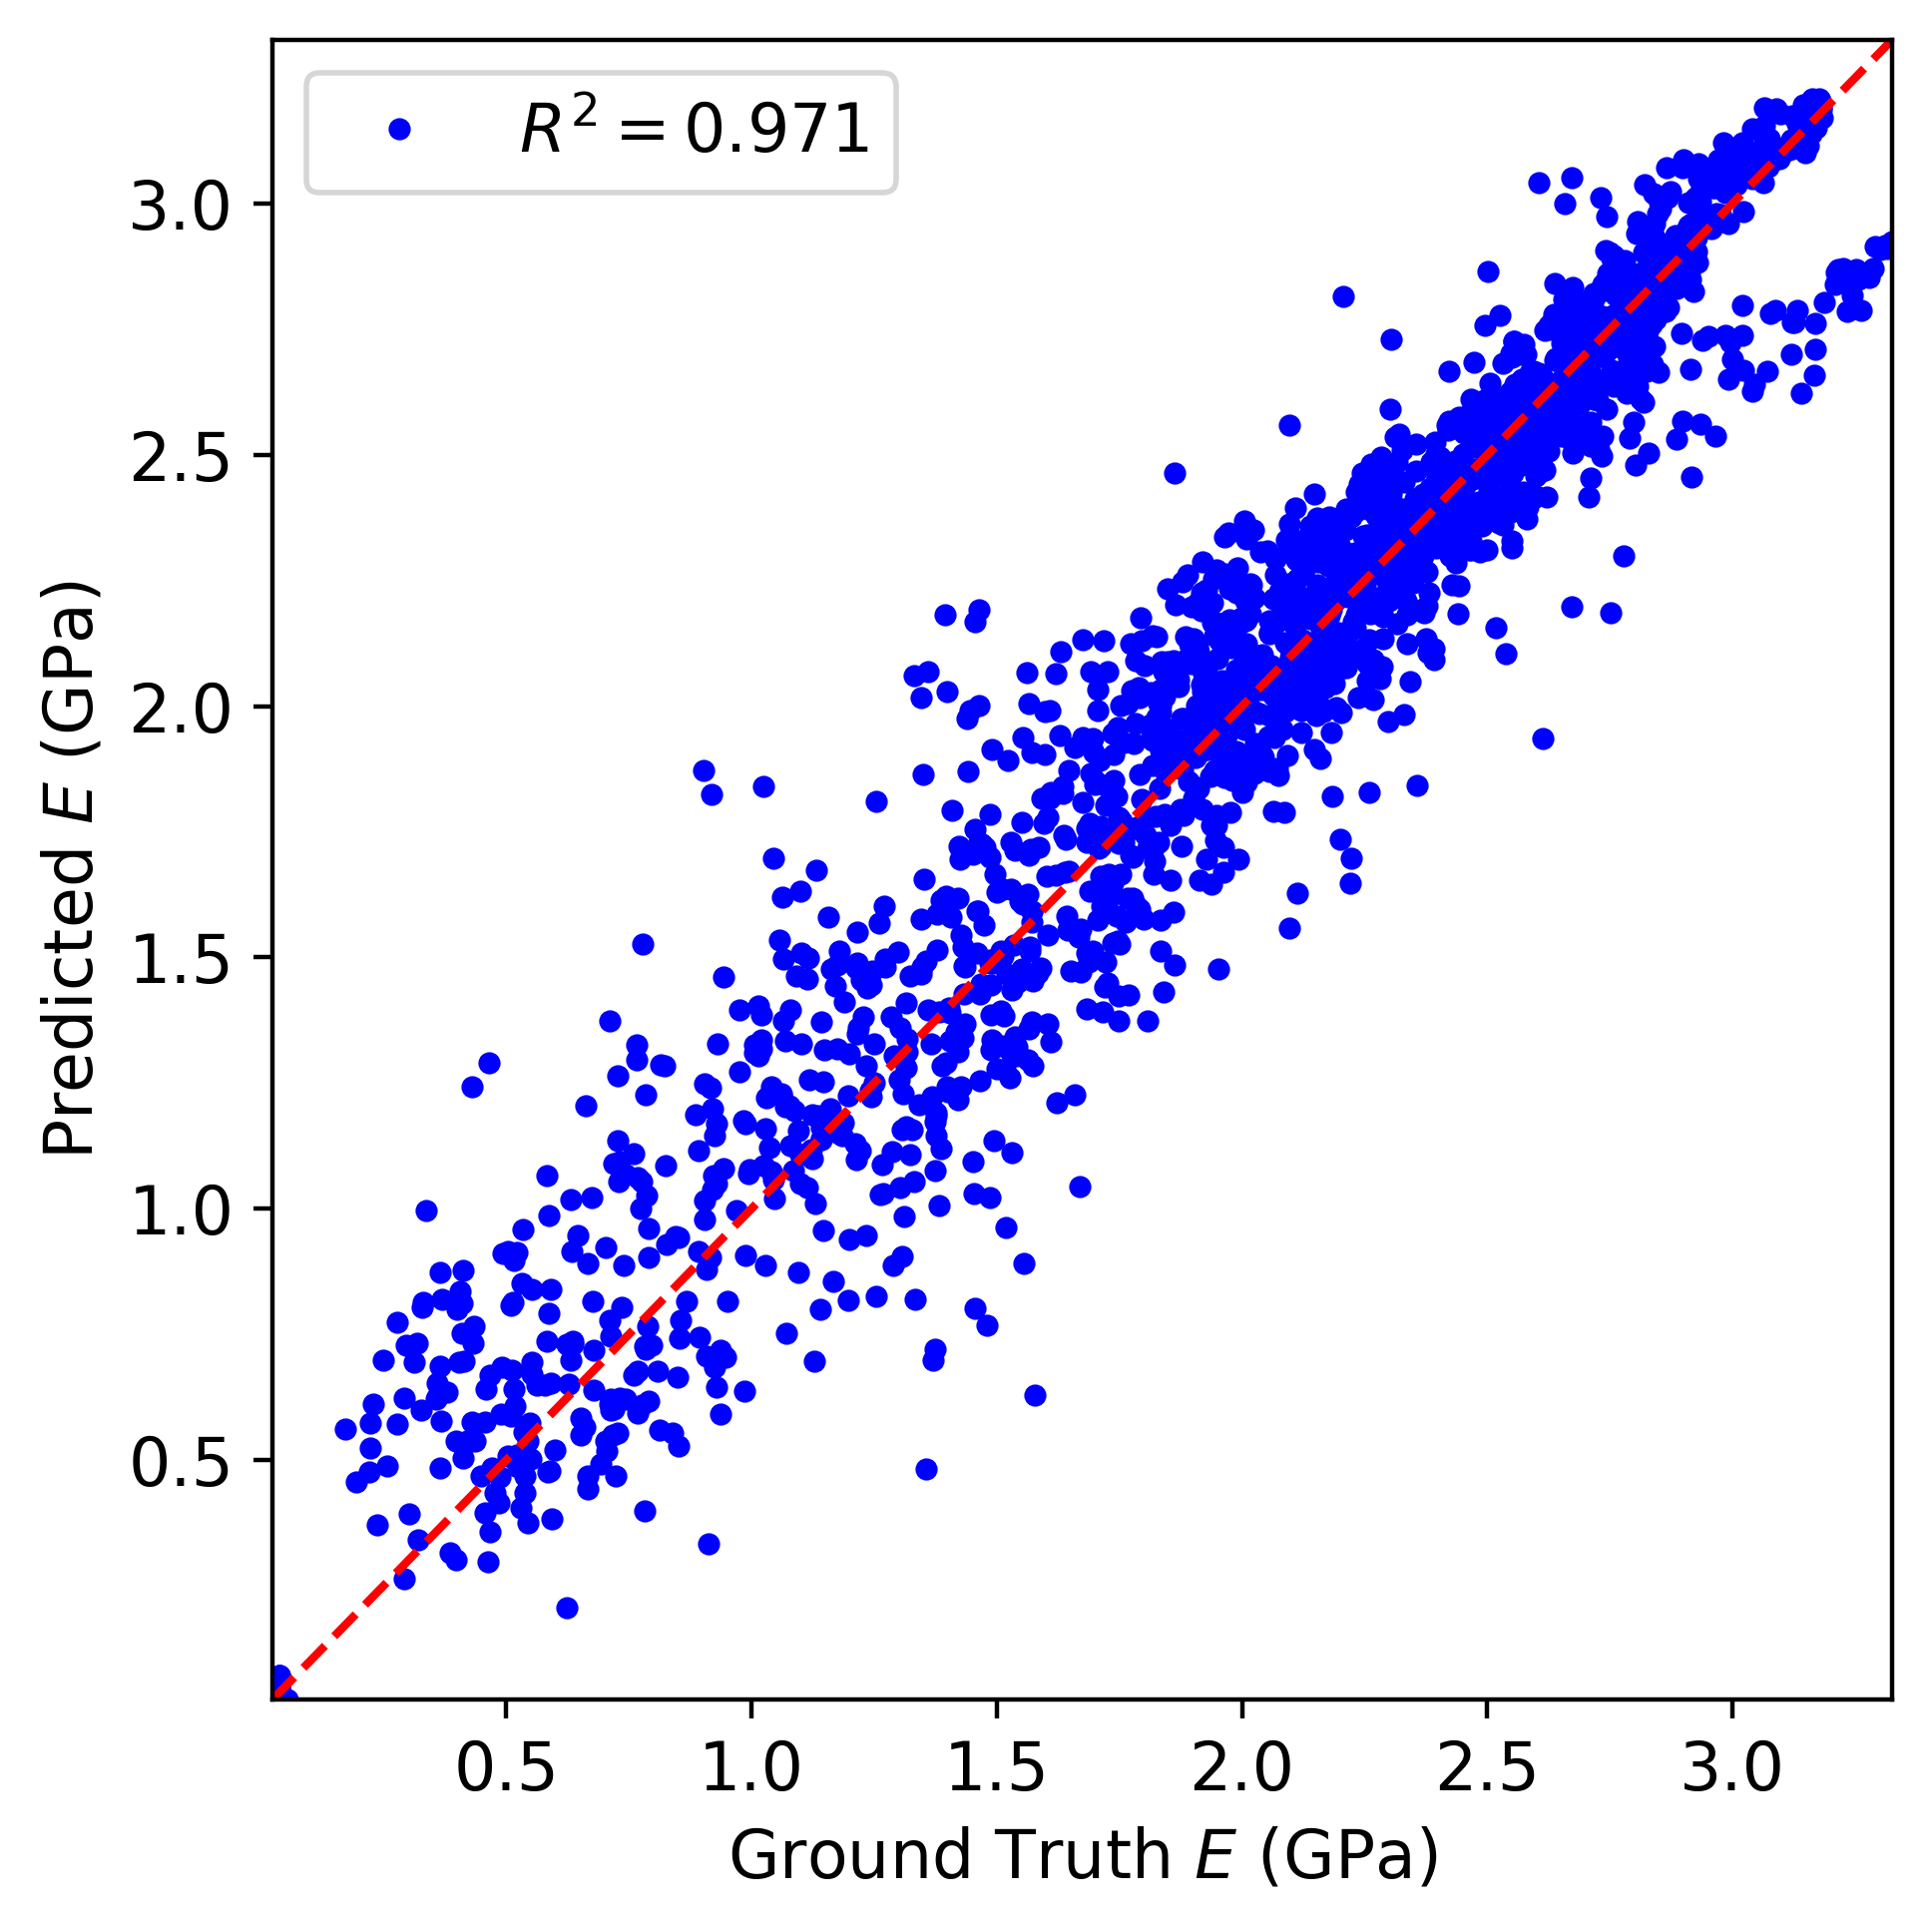

In [17]:
R2, bias = evaluate_model(model, test_loader, device, args.cover_interval, overlap, args.save_model_dir, split_name="test")